Internal absorption
====================

In [1]:
import jetset
print('tested with',jetset.__version__)

tested with 1.4.0rc1


In this tutorial we show how to use the internal absorption for external radiative fields.

We first create a leptonic jet model with e EC components.

In [2]:
from jetset.jet_model import Jet
import numpy as np
from jetset.template_2Dmodel import EBLAbsorptionTemplate
import astropy.units as u

ebl_dominguez_2010=EBLAbsorptionTemplate.from_name('Dominguez_2010_v2011')
ebl_dominguez_lopez=EBLAbsorptionTemplate.from_name('Dominguez_2023')
ebl_finke=EBLAbsorptionTemplate.from_name('Finke_2010')
ebl_franceschini=EBLAbsorptionTemplate.from_name('Franceschini_2008')


jetset_model = Jet(name="compact_int_abs",emitters_distribution="bkn",beaming_expr='bulk_theta')
jetset_model.add_EC_component(EC_components_list=['EC_DT','EC_BLR'],disk_type='BB')
jetset_model.make_conical_jet(theta_open=5,R=1E16)
jetset_model.set_EC_dependencies()

jetset_model.set_par('L_Disk',val=2E45)
jetset_model.set_par('gmax',val=5E5)
jetset_model.set_par('gmin',val=2.)
jetset_model.set_par('R_H',val=1E17)

jetset_model.set_par('p',val=1.5)
jetset_model.set_par('p_1',val=3.2)
jetset_model.set_par('B',val=1.5)
jetset_model.set_par('z_cosm',val=0.6)
jetset_model.set_par('BulkFactor',val=10)
jetset_model.set_par('theta',val=1)
jetset_model.set_par('gamma_break',val=5E2)
jetset_model.parameters.tau_DT.val=0.1
jetset_model.parameters.T_DT.val=1000
jetset_model.parameters.theta.freeze()
jetset_model.parameters.R_H.val=1E18
jetset_model.set_N_from_nuFnu(nu_obs=1E13,nuFnu_obs=1E-13)
jetset_model.set_external_field_transf('blob')



adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 1.1430052302761344e+17
adding par: L_Disk to  R_BLR_in
==> par R_BLR_in is depending on ['L_Disk'] according to expr:   R_BLR_in =
3E17*(L_Disk/1E46)**0.5
adding par: R_BLR_in to  R_BLR_out
==> par R_BLR_out is depending on ['R_BLR_in'] according to expr:   R_BLR_out =
R_BLR_in*1.1
adding par: L_Disk to  R_DT
==> par R_DT is depending on ['L_Disk'] according to expr:   R_DT =
2E19*(L_Disk/1E46)**0.5


Now we can enable the internal absorption for the BLR and DT fields, and evaluate the model with internal absorption applied

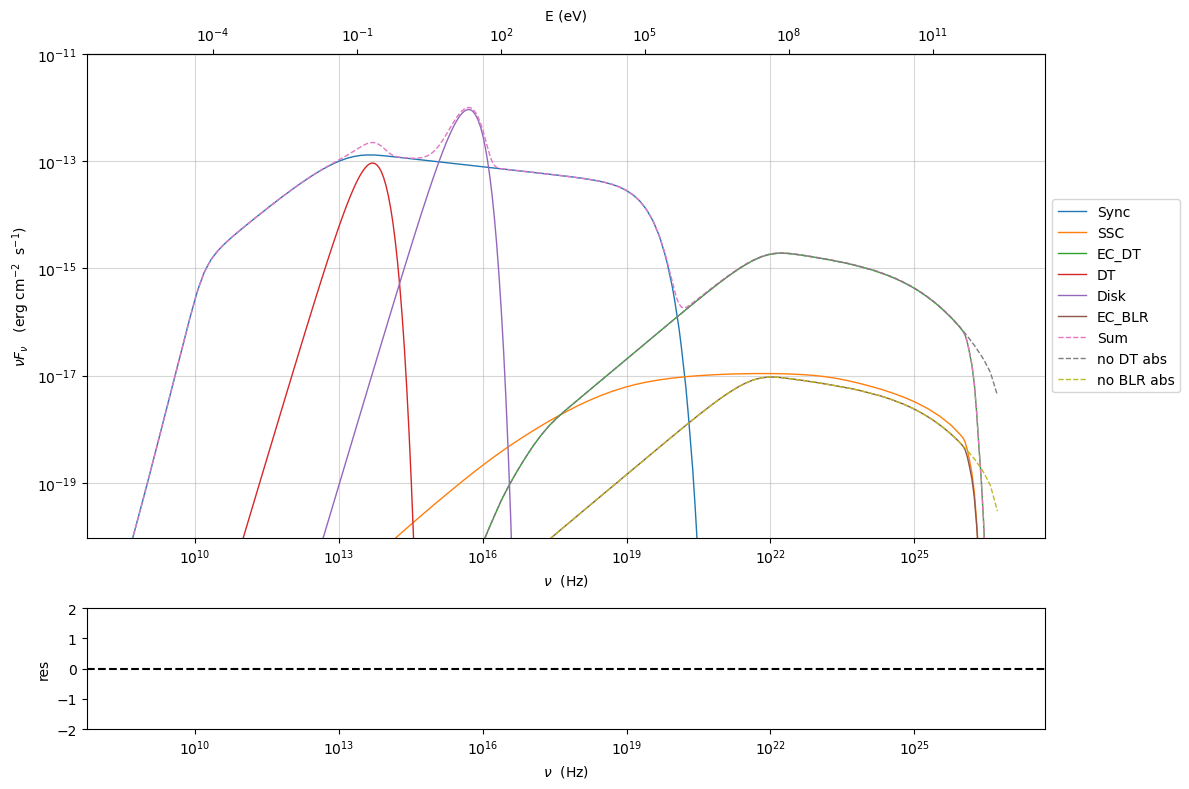

In [3]:

jetset_model.enable_internal_absorption('DT')
jetset_model.enable_internal_absorption('BLR')
jetset_model.eval()
p=jetset_model.plot_model()

jetset_model.remove_internal_absorption('DT')
jetset_model.remove_internal_absorption('BLR')
jetset_model.eval()
jetset_model.plot_model(plot_obj=p,comp='EC_DT',label='no DT abs',line_style='--')
jetset_model.plot_model(plot_obj=p,comp='EC_BLR',label='no BLR abs',line_style='--')



In [4]:

jetset_model.enable_internal_absorption('DT')
jetset_model.enable_internal_absorption('BLR')

This model can be used now for model fitting.

In [5]:
jetset_model.show_internal_absorption_components()

internal absorption  for component: DT
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'DT')
('use_R_H_profile_extrapolation', False)

internal absorption  for component: BLR
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'BLR')
('use_R_H_profile_extrapolation', False)



Please, notice that the internal absorption will slow down a bit the computation. Let's quantify the effect for a single component. 
First we remove the BLR absorption

In [6]:
jetset_model.remove_internal_absorption('BLR')
jetset_model.show_internal_absorption_components()

internal absorption  for component: DT
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'DT')
('use_R_H_profile_extrapolation', False)



In [7]:
%timeit jetset_model.eval()

13.4 ms ± 78 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:
jetset_model.remove_internal_absorption('DT')


In [9]:
jetset_model.set_num_c_threads(6)
%timeit jetset_model.eval()
jetset_model.show_internal_absorption_components()

6.28 ms ± 120 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
internal absorption not enabled in this jet model


The increase in computational time, for component, compared to an EC model without absorption, is of a factor of ~ 4. 


By setting `use_R_H_profile_extrapolation=True`, we can speed up the process

In [61]:
jetset_model.enable_internal_absorption('DT',use_R_H_profile_extrapolation=True)


In [59]:
jetset_model.remove_internal_absorption('DT')
#jetset_model.remove_internal_absorption('BLR')

In [54]:
jetset_model.set_num_c_threads(14)

In [62]:
jetset_model.spectral_components.SSC.state='on'
jetset_model.spectral_components.Sync.state='self-abs'
jetset_model.spectral_components.EC_BLR.state='off'
jetset_model.spectral_components.EC_DT.state='on'
jetset_model.spectral_components.DT.state='on'
jetset_model.spectral_components.Disk.state='off'
jetset_model.show_internal_absorption_components()
%timeit jetset_model.eval()

internal absorption  for component: DT
('N_hard', 50)
('N_soft', 50)
('N_theta', 50)
('N_R_H', 50)
('nu_min', 1e+20)
('comp', 'DT')
('use_R_H_profile_extrapolation', True)

5.87 ms ± 31 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [44]:
jetset_model._blob.core.do_DT

0

In [57]:
1.4+3.91

5.3100000000000005

In [64]:
%timeit _=jetset_model.eval_internal_absorption(comp='DT', peak=False)

3.9 ms ± 67.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


The increase in computational time is lower now, down to a factor of ~2 per absorption component. 



In the following some plots showing the accuracy effect when using `use_R_H_profile_extrapolation=True`, so you can choose accordingly, if whether to use the approximation or not.

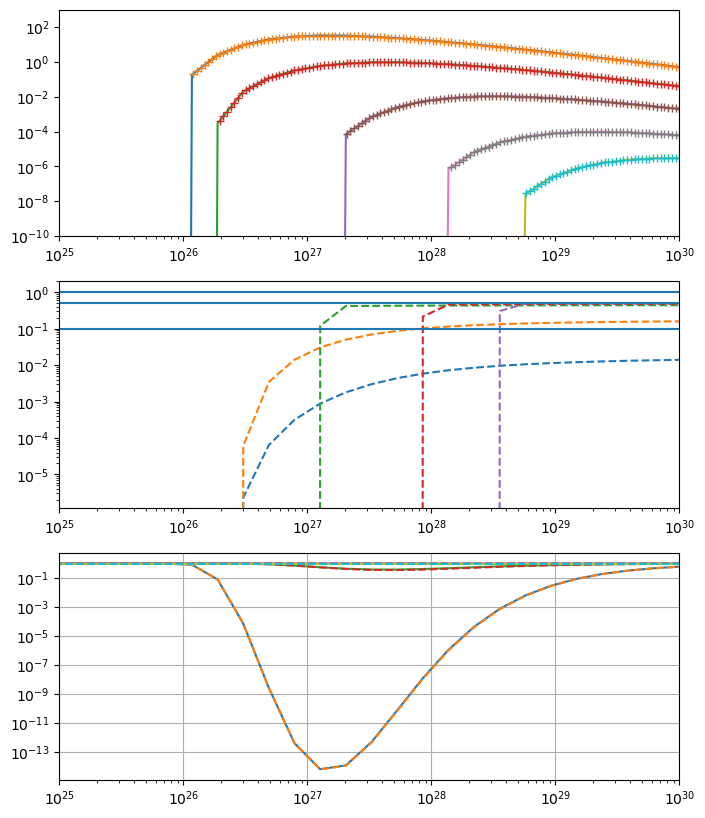

In [14]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
fig,axs=plt.subplots(3,1,figsize=(8,10))
nu_tau=np.logspace(24,30,30)
R_DT=jetset_model.parameters.R_DT.val
for f in [0.1,1,2,5,10]:
    jetset_model.parameters.R_H.val=R_DT*f
    jetset_model.enable_internal_absorption('DT',N_R_H=50,N_theta=50,N_soft=50,N_hard=100,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp='DT',peak=False,nu=nu_tau)
    x=x*u.Hz
    x1=np.logspace(24,30,200)
    tau_interp = 10**np.interp(np.log10(x1), np.log10(x.value), np.log10(y))
 
    axs[0].loglog( x,y)
    axs[0].loglog( x1,tau_interp,'+')


    jetset_model.enable_internal_absorption('DT',N_R_H=50,N_theta=50,N_soft=50,N_hard=100,use_R_H_profile_extrapolation=True)
    y1,x=jetset_model.eval_internal_absorption(comp='DT',peak=False,nu=nu_tau)

    x=x*u.Hz
 

    axs[1].loglog( x,np.fabs(y1-y)/y,'--')

    axs[2].loglog( x,np.exp(-y),'-')
    axs[2].loglog( x,np.exp(-y1),'--')
axs[0].set_xlim(1E25,1E30)
axs[1].set_xlim(1E25,1E30)
axs[2].set_xlim(1E25,1E30)

axs[1].axhline(1)   
axs[1].axhline(.5)
axs[1].axhline(.1)
axs[0].set_ylim(1E-10,1E3)

axs[1].set_ylim(None,2)
plt.grid()

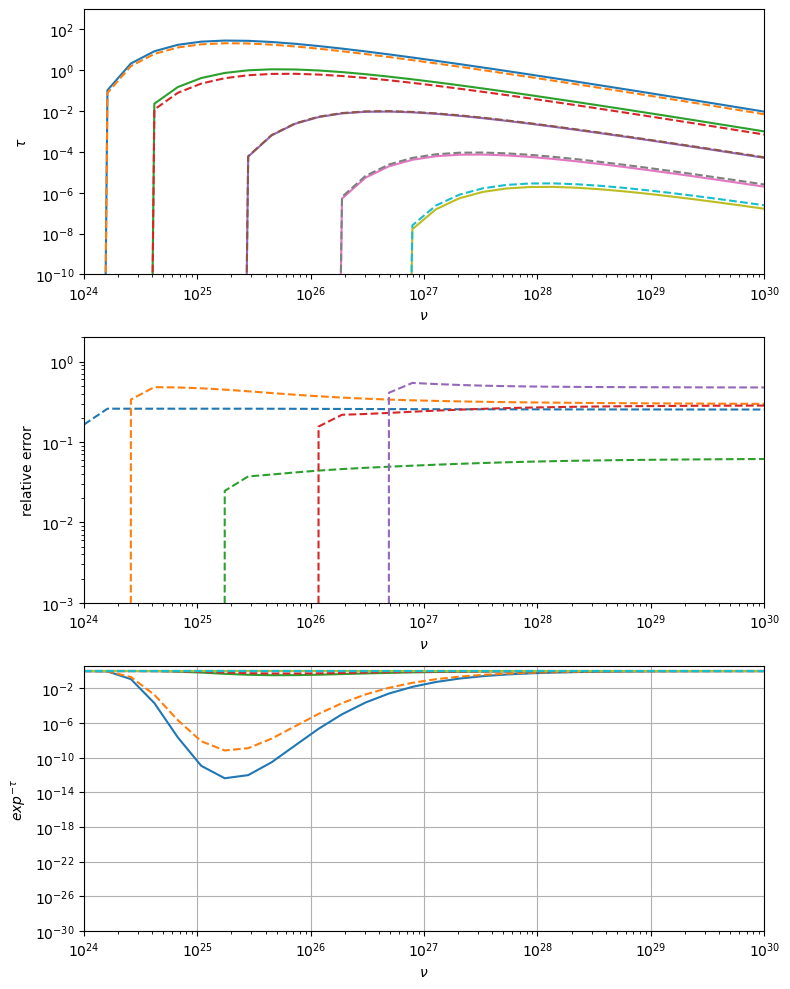

In [15]:
from matplotlib import pylab as plt
jetset_model.parameters.tau_BLR.val=0.1
#jetset_model.parameters.T_DT.val=1000
fig,axs=plt.subplots(3,1,figsize=(8,10))
nu_tau=np.logspace(24,30,30)
R_BLR=jetset_model.parameters.R_BLR_out.val
for f in [0.1,1,2,5,10]:
    jetset_model.parameters.R_H.val=R_BLR*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption('BLR',N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp='BLR',peak=False,nu=nu_tau)

    x=x*u.Hz
 
    axs[0].loglog( x,y)

    jetset_model.enable_internal_absorption('BLR',N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True)
    y1,x=jetset_model.eval_internal_absorption(comp='BLR',peak=False,nu=nu_tau)

    x=x*u.Hz
 
    axs[0].loglog( x,y1,'--')

    axs[1].loglog( x,np.fabs(y1-y)/y,'--')

    axs[2].loglog( x,np.exp(-y),'-')
    axs[2].loglog( x,np.exp(-y1),'--')
axs[0].set_xlim(1E24,1E30)

axs[1].set_xlim(1E24,1E30)
axs[2].set_xlim(1E24,1E30)

#axs[1].axhline(1)   
#axs[1].axhline(.5)
#axs[1].axhline(.1)
axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-3,2)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.tight_layout()
plt.grid()

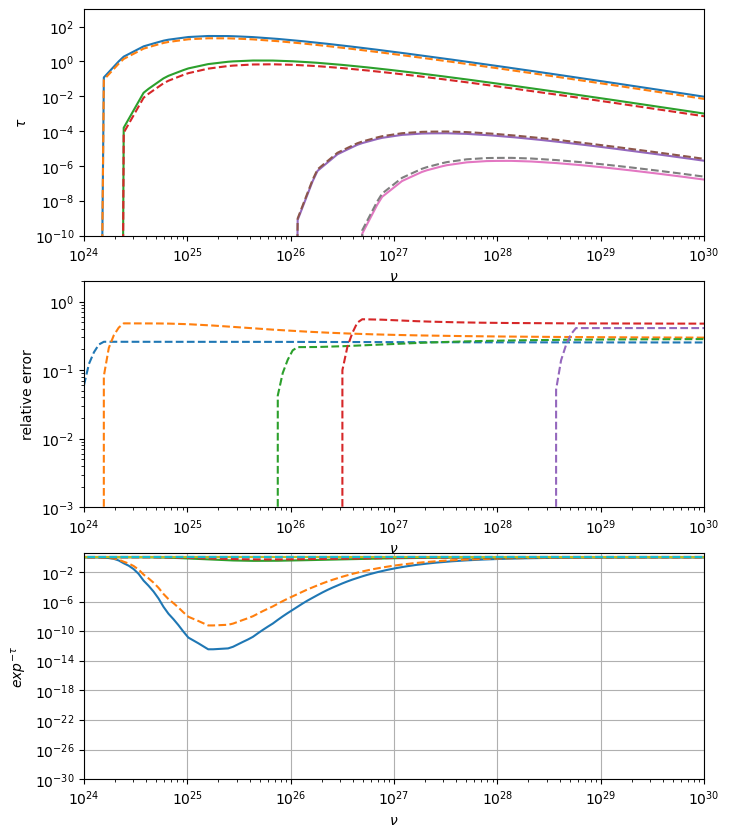

In [16]:
jetset_model.parameters.tau_BLR.val=0.1
R_BLR=jetset_model.parameters.R_BLR_out.val
fig,axs=plt.subplots(3,1,figsize=(8,10))
for f in [0.1,1,5,10,100]:
    jetset_model.parameters.R_H.val=R_BLR*f
    jetset_model.eval()
    jetset_model.enable_internal_absorption('BLR',N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=False)
    y,x=jetset_model.eval_internal_absorption(comp="BLR",peak=False)
    x=x*u.Hz
 
    axs[0].loglog( x,y,)
    jetset_model.enable_internal_absorption('BLR',N_R_H=50,N_theta=50,N_soft=50,N_hard=50,use_R_H_profile_extrapolation=True)
    y1,x=jetset_model.eval_internal_absorption(comp="BLR",peak=False)
    x=x*u.Hz
    
    axs[0].loglog( x,y1,'--')

    axs[1].loglog( x,np.fabs(y1-y)/y,'--')
    axs[2].loglog( x,np.exp(-y),'-')
    axs[2].loglog( x,np.exp(-y1),'--')
axs[0].set_xlim(1E24,1E30)
axs[1].set_xlim(1E24,1E30)
axs[2].set_xlim(1E24,1E30)

#axs[1].axhline(1)   
#axs[1].axhline(.5)
#axs[1].axhline(.1)
axs[0].set_ylim(1E-10,1E3)
axs[1].set_ylim(1E-3,2)
axs[2].set_ylim(1E-30,)
axs[0].set_xlabel(r'$\nu$')
axs[1].set_xlabel(r'$\nu$')
axs[2].set_xlabel(r'$\nu$')

axs[0].set_ylabel(r'$\tau$')
axs[1].set_ylabel(r'relative error')
axs[2].set_ylabel(r'$exp^{-\tau}$')
plt.grid()
